In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Herramientas de machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
#evaluacion
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve #visualizar la metrica




credit_df = pd.read_csv("../data/raw/loan_approval.csv")
credit_df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [3]:
credit_df.shape
credit_df.info()
credit_df.isnull().sum() #Missing values 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [4]:
credit_df.columns #hay espacios al comienzo de cada variable, salvo la primera que es 'loan_id'

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [5]:
credit_df.columns = credit_df.columns.str.strip().str.lower()#Limpiamos los espacios
credit_df.columns


Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [6]:
credit_df['loan_status'].value_counts(normalize=True)


 Approved    0.62216
 Rejected    0.37784
Name: loan_status, dtype: float64

El dataset presenta una distribución relativamente balanceada entre créditos aprobados (≈62%) y rechazados (≈38%).
No se observa un desbalance severo, por lo que inicialmente no es necesario aplicar técnicas de balanceo de clases.
Este aspecto se evaluará nuevamente en función de las métricas del modelo.

In [7]:
credit_df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [8]:
credit_df = credit_df.drop(columns=['loan_id'])

In [9]:
credit_df['residential_assets_value'] = (
    credit_df['residential_assets_value'].clip(lower=0)
)
# Corrección de valores negativos en activos residenciales
# En la realidad, un activo no puede tener valor negativo.
# Se asume que valores negativos son errores de carga o placeholders.

In [10]:
credit_df['residential_assets_value'].describe()

count    4.269000e+03
mean     7.473272e+06
std      6.502878e+06
min      0.000000e+00
25%      2.200000e+06
50%      5.600000e+06
75%      1.130000e+07
max      2.910000e+07
Name: residential_assets_value, dtype: float64

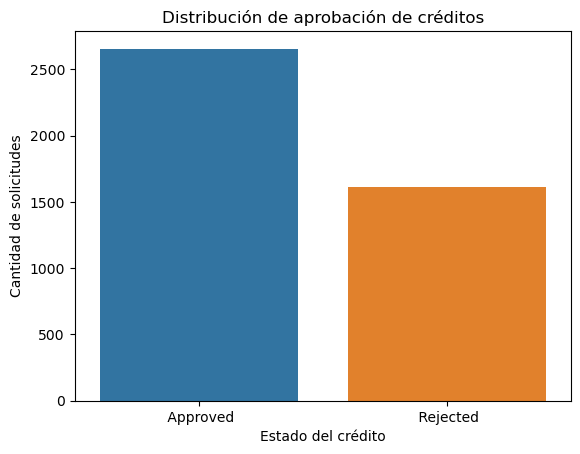

In [11]:
# Visualizamos la distribución del target (aprobado vs rechazado)
# Esto permite evaluar el balance de clases antes de entrenar el modelo
sns.countplot(x='loan_status', data=credit_df)
plt.title('Distribución de aprobación de créditos')
plt.xlabel('Estado del crédito')
plt.ylabel('Cantidad de solicitudes')
plt.show()

In [12]:
credit_df.dtypes

no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

In [13]:
# Definimos las columnas numéricas del dataset
# Estas variables representan ingresos, endeudamiento, score crediticio y activos
# Se utilizan para el análisis de correlación y EDA numérico
num_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value',
    'loan_status'  # incluimos el target para ver su relación con las variables
]

C:\Users\frann\AppData\Local\Temp\ipykernel_2560\3273528300.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = credit_df[num_cols].corr()


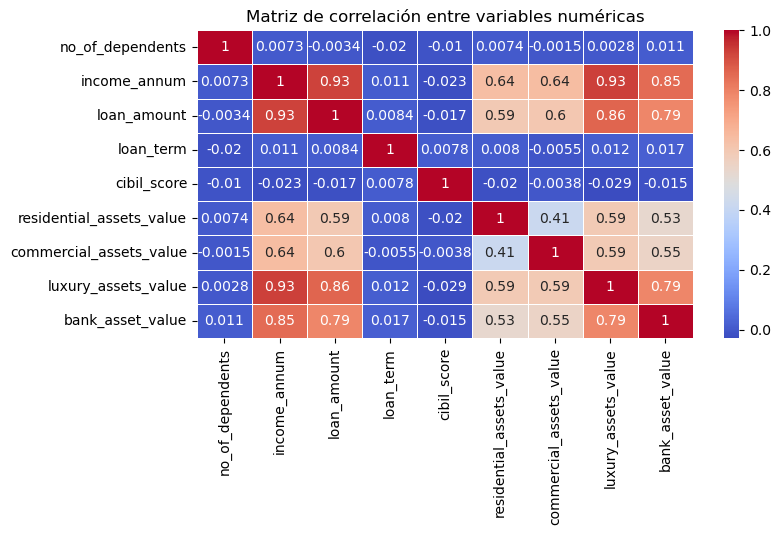

In [14]:
# Calculamos la matriz de correlación solo con columnas numéricas relevantes
corr_matrix = credit_df[num_cols].corr()

# Visualizamos la matriz de correlación
plt.figure(figsize=(8, 4))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    linewidths=0.5
)
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

Hallazgos Principales:
Relación Ingresos-Préstamo (0.93): Existe una correlación positiva casi perfecta entre income_annum y loan_amount. Esto indica que el monto del préstamo otorgado está directamente ligado a la capacidad de generación de ingresos del solicitante.

Dependencia de Activos: Se observa una correlación alta (aprox. 0.93) entre el ingreso anual y el valor de los activos de lujo (luxury_assets_value). Asimismo, los activos bancarios y comerciales muestran una relación sólida con el monto del préstamo, lo que sugiere que funcionan como colateral o garantía.

Independencia del CIBIL Score: Notablemente, el cibil_score presenta una correlación cercana a cero con el resto de las variables financieras. Esto significa que tener altos ingresos o muchos activos no garantiza un buen historial crediticio; el score se comporta como una variable independiente y crítica para el modelo.

Factores Demográficos y Plazos: Variables como el número de dependientes (no_of_dependents) y el plazo del préstamo (loan_term) no muestran una relación lineal significativa con el nivel de riqueza o el monto solicitado.

Conclusión para el Modelo: Dado que income_annum y loan_amount están altamente correlacionados, presentan multicolinealidad. Para el entrenamiento de modelos de Machine Learning, esto sugiere que una de estas variables podría ser redundante o que ambas deben ser tratadas con cuidado para no sesgar el algoritmo.

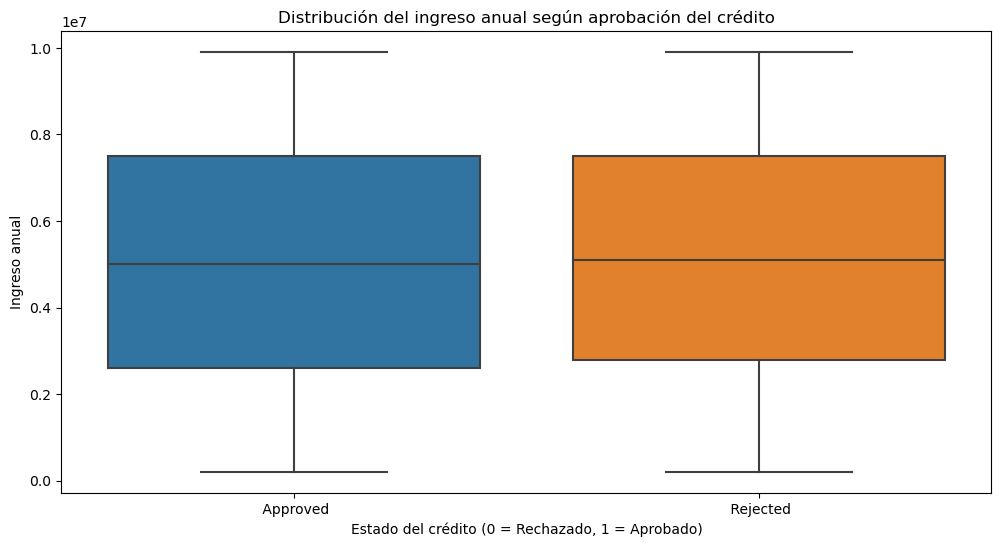

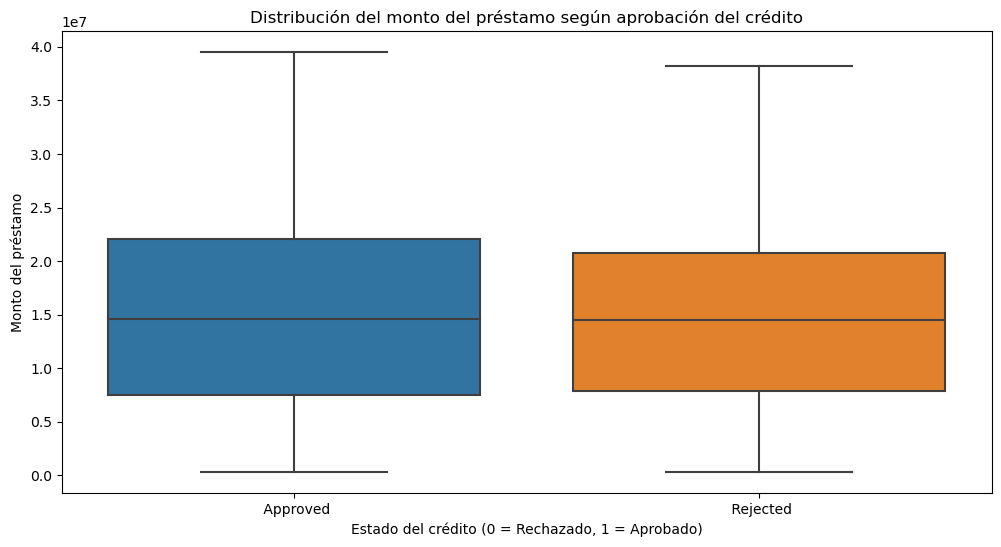

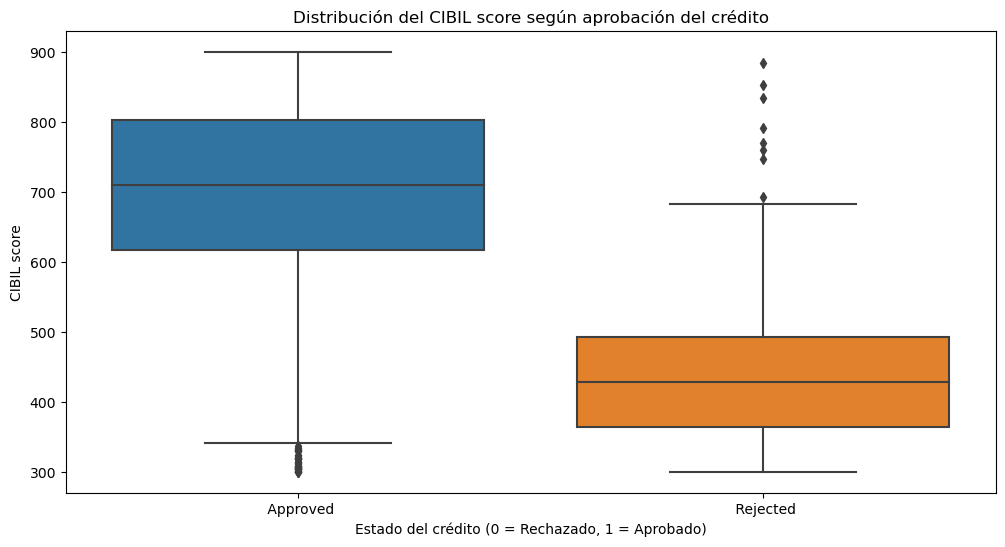

In [15]:
# Boxplot de ingresos vs estado del crédito
# Permite visualizar la distribución de ingresos según si el crédito fue aprobado o rechazado
plt.figure(figsize=(12,6))
sns.boxplot(x='loan_status', y='income_annum', data=credit_df)
plt.title('Distribución del ingreso anual según aprobación del crédito')
plt.xlabel('Estado del crédito (0 = Rechazado, 1 = Aprobado)')
plt.ylabel('Ingreso anual')
plt.show()

# Boxplot del monto del préstamo vs estado del crédito
plt.figure(figsize=(12,6))
sns.boxplot(x='loan_status', y='loan_amount', data=credit_df)
plt.title('Distribución del monto del préstamo según aprobación del crédito')
plt.xlabel('Estado del crédito (0 = Rechazado, 1 = Aprobado)')
plt.ylabel('Monto del préstamo')
plt.show()

# Boxplot del CIBIL score vs estado del crédito
plt.figure(figsize=(12,6))
sns.boxplot(x='loan_status', y='cibil_score', data=credit_df)
plt.title('Distribución del CIBIL score según aprobación del crédito')
plt.xlabel('Estado del crédito (0 = Rechazado, 1 = Aprobado)')
plt.ylabel('CIBIL score')
plt.show()


In [16]:
print(credit_df['loan_status'].head())

0     Approved
1     Rejected
2     Rejected
3     Rejected
4     Rejected
Name: loan_status, dtype: object


In [17]:
# Mapear la variable target a valores numéricos
# Approved → 1, Rejected → 0
credit_df['loan_status'] = credit_df['loan_status'].str.strip().str.capitalize()
credit_df['loan_status'] = credit_df['loan_status'].map({'Approved':1,'Rejected':0})
print(credit_df['loan_status'].value_counts())



1    2656
0    1613
Name: loan_status, dtype: int64


In [18]:
print(credit_df.describe(include='all'))

        no_of_dependents  education self_employed  income_annum   loan_amount  \
count        4269.000000       4269          4269  4.269000e+03  4.269000e+03   
unique               NaN          2             2           NaN           NaN   
top                  NaN   Graduate           Yes           NaN           NaN   
freq                 NaN       2144          2150           NaN           NaN   
mean            2.498712        NaN           NaN  5.059124e+06  1.513345e+07   
std             1.695910        NaN           NaN  2.806840e+06  9.043363e+06   
min             0.000000        NaN           NaN  2.000000e+05  3.000000e+05   
25%             1.000000        NaN           NaN  2.700000e+06  7.700000e+06   
50%             3.000000        NaN           NaN  5.100000e+06  1.450000e+07   
75%             4.000000        NaN           NaN  7.500000e+06  2.150000e+07   
max             5.000000        NaN           NaN  9.900000e+06  3.950000e+07   

          loan_term  cibil_

In [19]:
credit_df['loan_status']

0       1
1       0
2       0
3       0
4       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4269, dtype: int64

In [20]:
#Lista de variables categóricas
cat_cols = ['education', 'self_employed']

#Crear variables dummy (0/1) para cada categoría
credit_df = pd.get_dummies(credit_df, columns=cat_cols, drop_first=True)

print(credit_df.head())
print(credit_df.columns)

   no_of_dependents  income_annum  loan_amount  loan_term  cibil_score  \
0                 2       9600000     29900000         12          778   
1                 0       4100000     12200000          8          417   
2                 3       9100000     29700000         20          506   
3                 3       8200000     30700000          8          467   
4                 5       9800000     24200000         20          382   

   residential_assets_value  commercial_assets_value  luxury_assets_value  \
0                   2400000                 17600000             22700000   
1                   2700000                  2200000              8800000   
2                   7100000                  4500000             33300000   
3                  18200000                  3300000             23300000   
4                  12400000                  8200000             29400000   

   bank_asset_value  loan_status  education_ Not Graduate  self_employed_ Yes  
0           

In [21]:
# Scalar los datos, (solo variables continuas)

num_cols_scale = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
    #'loan_status' queda afuera porque nunca se escala la variable target
]

In [22]:
scaler = StandardScaler()
credit_df[num_cols_scale] = scaler.fit_transform(credit_df[num_cols_scale])
credit_df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,-0.294102,1.617979,1.633052,0.192617,1.032792,-0.780249,2.877289,0.832028,0.930304,1,0,0
1,-1.473548,-0.341750,-0.324414,-0.508091,-1.061051,-0.734111,-0.631921,-0.694993,-0.515936,0,1,1
2,0.295621,1.439822,1.610933,1.594031,-0.544840,-0.057408,-0.107818,1.996520,2.407316,0,0,0
3,0.295621,1.119139,1.721525,-0.508091,-0.771045,1.649729,-0.381263,0.897943,0.899533,0,0,0
4,1.475067,1.689242,1.002681,1.594031,-1.264055,0.757711,0.735304,1.568075,0.007172,0,1,1


# Dividir los datos
1. Datos de entrenamiento
2. Datos para aprobar el model



In [23]:
# Variables predictoras
X = credit_df.drop(columns=['loan_status'])

# Variable objetivo
y = credit_df['loan_status']

In [24]:
X

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
0,-0.294102,1.617979,1.633052,0.192617,1.032792,-0.780249,2.877289,0.832028,0.930304,0,0
1,-1.473548,-0.341750,-0.324414,-0.508091,-1.061051,-0.734111,-0.631921,-0.694993,-0.515936,1,1
2,0.295621,1.439822,1.610933,1.594031,-0.544840,-0.057408,-0.107818,1.996520,2.407316,0,0
3,0.295621,1.119139,1.721525,-0.508091,-0.771045,1.649729,-0.381263,0.897943,0.899533,0,0
4,1.475067,1.689242,1.002681,1.594031,-1.264055,0.757711,0.735304,1.568075,0.007172,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4264,1.475067,-1.446324,-1.419268,0.192617,-1.641063,-0.718731,-1.019301,-1.299210,-1.285213,0,1
4265,-1.473548,-0.626801,-0.423946,1.594031,-0.237434,-0.503416,-0.472412,-0.453306,-0.946732,1,1
4266,-0.294102,0.513405,0.969504,1.243677,-0.829046,-0.964805,1.692361,0.326683,0.714907,1,0
4267,-0.883825,-0.341750,-0.258059,-0.508091,1.044393,0.111768,-0.973727,-0.112748,0.253341,1,0


In [25]:
y


0       1
1       0
2       0
3       0
4       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4269, dtype: int64

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

# vemos el tamaño de los datos
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3415, 11), (854, 11), (3415,), (854,))

In [27]:
# pasamos a la modelacion usando regresion logistica

log_reg = LogisticRegression(max_iter = 1000, random_state = 42, n_jobs= -1)

log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)

In [28]:
# Predicciones y probabilidades 
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test) [:,1]


In [29]:
y_pred_lr


array([0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,

In [30]:
y_prob_lr

array([3.29713545e-02, 8.43431329e-01, 2.50093526e-02, 9.61791025e-01,
       9.89155472e-01, 9.78473684e-01, 9.89051422e-01, 3.76435507e-01,
       7.58478784e-01, 2.20847796e-01, 6.20044499e-01, 9.93146634e-01,
       9.89367677e-01, 6.41586118e-02, 3.61608637e-02, 9.67181955e-01,
       9.80683106e-01, 7.32557271e-01, 3.09719787e-02, 6.94783564e-02,
       7.83550978e-01, 1.67477933e-02, 1.18661294e-01, 9.00607525e-02,
       9.97101868e-01, 9.78698183e-01, 9.99223395e-01, 7.43322621e-01,
       9.98308829e-01, 1.26728937e-01, 8.97617392e-01, 3.14755061e-02,
       7.01543424e-01, 8.42997487e-01, 2.46774706e-03, 4.05153267e-02,
       8.82885258e-01, 8.91357684e-01, 9.99775492e-01, 1.05625953e-02,
       3.79655114e-01, 8.96995264e-01, 9.99826308e-01, 9.99907989e-01,
       3.25044041e-01, 9.61709448e-01, 9.99374046e-01, 9.70261753e-01,
       9.99776139e-01, 4.20663787e-02, 9.95581789e-01, 4.67157362e-01,
       4.46293804e-01, 9.99743557e-01, 9.92320858e-01, 9.93284509e-01,
      

- 0.03 → cliente con 97% probabilidad de rechazo
- 0.84 → cliente muy probable aprobado
- 0.55 → cliente zona gris
- 0.99 → cliente excelente perfil crediticio

In [31]:
#Evaluacion del modelo
print("\nEvaluacion para el Modelo de Regresion Logistica")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}") #:.4f solo 4 numeros decimales
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"Roc-AUC: {roc_auc_score(y_test, y_pred_lr):.4f}")


Evaluacion para el Modelo de Regresion Logistica
Accuracy: 0.9052
Precision: 0.9205
Recall: 0.9291
F1-Score: 0.9248
Roc-AUC: 0.8969


In [32]:
#Evaluacion del modelo
print("\nEvaluacion para el Modelo de Regresion Logistica")
print(f"Roc-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}") #Eso te va a dar el AUC real del modelo.



Evaluacion para el Modelo de Regresion Logistica
Roc-AUC: 0.9675


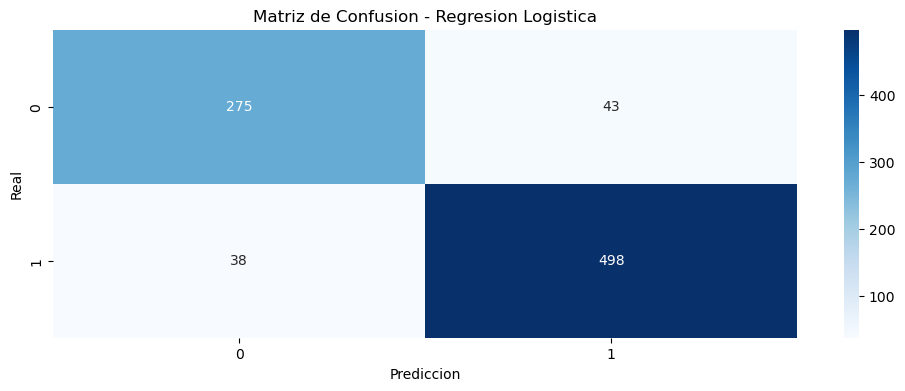

In [33]:
# Matriz de Confusion

conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize = (12, 4))
sns.heatmap(conf_matrix_lr, annot= True, fmt = 'd', cmap= 'Blues')
plt.title("Matriz de Confusion - Regresion Logistica")
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()


La matriz de confusión indica que el modelo presenta un desempeño sólido y consistente. Se observa una alta capacidad para identificar correctamente tanto créditos aprobados (498 casos) como rechazados (275 casos).

Es especialmente relevante la baja cantidad de falsos positivos (43), ya que en el contexto de riesgo crediticio este tipo de error representa una pérdida financiera directa.

Asimismo, los falsos negativos (38) reflejan oportunidades de negocio perdidas, un trade-off aceptable en escenarios donde se prioriza la reducción del riesgo. En conjunto, el modelo demuestra un buen equilibrio entre rentabilidad y control de riesgo.

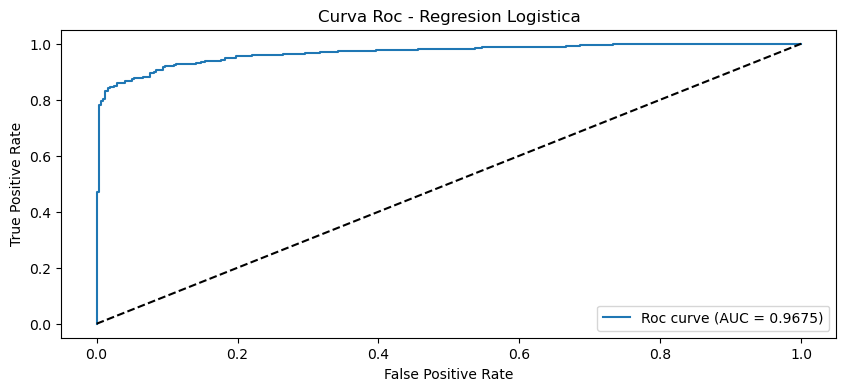

In [34]:
# curva Roc
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(10,4))
plt.plot(fpr, tpr, label = f'Roc curve (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title("Curva Roc - Regresion Logistica")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

La curva ROC muestra una excelente capacidad de discriminación del modelo, con un AUC de 0.9675. Esto indica que el modelo separa de manera efectiva a los clientes aprobados de los rechazados, manteniendo una alta tasa de verdaderos positivos incluso con bajos niveles de falsos positivos. Este comportamiento permite ajustar el umbral de decisión según la política de riesgo sin perder robustez predictiva.

**ROC-AUC de 0.9675**

Si tomamos al azar un cliente bueno y uno malo, el modelo tiene un 96.75% de probabilidad de asignarle una mayor probabilidad de aprobación al cliente bueno.


# Modelo Random Forest 

In [35]:
rf_clf = RandomForestClassifier(n_estimators = 1000, random_state = 42, n_jobs = -1, max_depth = 5)
rf_clf.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, n_estimators=1000, n_jobs=-1,
                       random_state=42)

In [36]:
#Predicciones y Probabilidad

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:,1]

In [37]:
y_pred_rf #pronosticos

array([0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,

In [38]:
y_prob_rf #probabilidades

array([0.14174545, 0.91377363, 0.13584224, 0.92384534, 0.90835498,
       0.89854961, 0.90544687, 0.12982056, 0.91137455, 0.13717326,
       0.15007959, 0.90678949, 0.90999498, 0.15939783, 0.13128907,
       0.91126014, 0.96519558, 0.46787137, 0.50331979, 0.13459213,
       0.90764563, 0.14178158, 0.15482094, 0.13885956, 0.90686709,
       0.91648005, 0.90886546, 0.90520015, 0.91559572, 0.13480088,
       0.90744281, 0.14050689, 0.14961175, 0.91078807, 0.13248701,
       0.13346013, 0.91898451, 0.90596901, 0.92429425, 0.13973627,
       0.13510725, 0.9498668 , 0.96023692, 0.90889245, 0.5209162 ,
       0.91500161, 0.93277191, 0.93834418, 0.91105069, 0.13898721,
       0.95988729, 0.43061305, 0.13205198, 0.90992111, 0.88760288,
       0.90790644, 0.90727056, 0.90861255, 0.43652686, 0.9124062 ,
       0.93616027, 0.92029664, 0.1435269 , 0.1290677 , 0.14156855,
       0.91834736, 0.91904389, 0.93646544, 0.86209552, 0.95125016,
       0.90679812, 0.87018564, 0.94833882, 0.90673925, 0.13039

In [39]:
#Evaluacion del modelo

print("\nEvaluacion para el Modelo Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"Roc-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


Evaluacion para el Modelo Random Forest
Accuracy: 0.9707
Precision: 0.9776
Recall: 0.9757
F1-Score: 0.9767
Roc-AUC: 0.9977


### Modelo seleccionado: Random Forest

- Supera ampliamente a la regresión logística en todas las métricas.

- Minimiza el riesgo financiero (bajos falsos positivos).

- Maximiza captación de clientes confiables (alto recall).

- Alta capacidad para capturar relaciones no lineales.

El modelo Random Forest demuestra un desempeño sobresaliente para tareas de credit scoring, logrando un balance óptimo entre riesgo y rentabilidad.

*Pese al excelente resultado, un ROC-AUC tan alto puede indicar un dataset muy limpio o potencial riesgo de overfitting, por lo que el modelo debe validarse con cross-validation y datos fuera de muestra.*

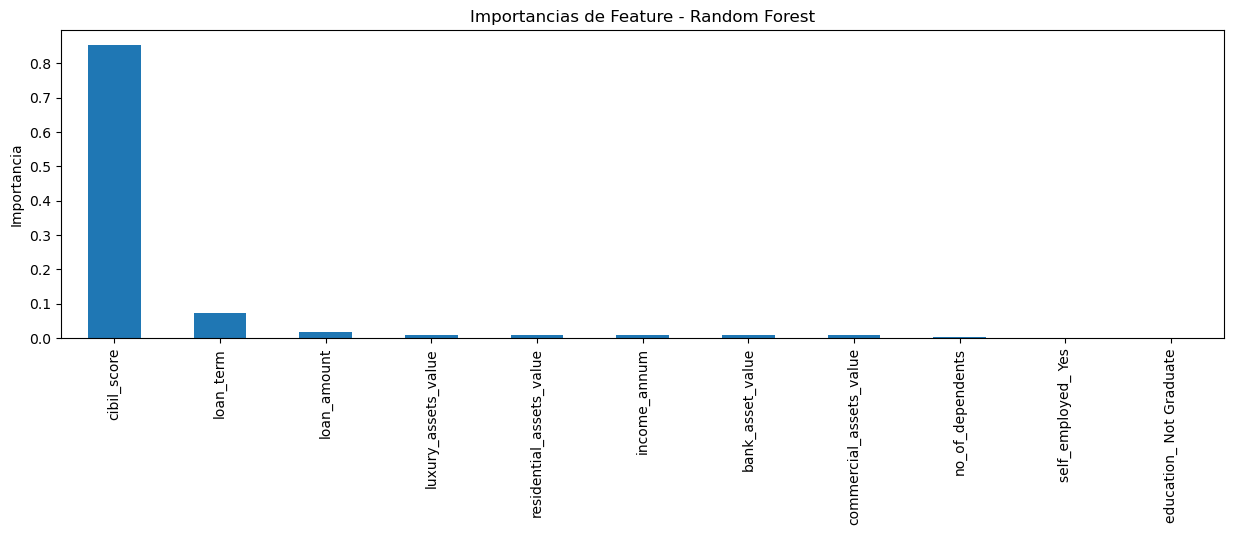

In [40]:
# Importancia de las caracteristicas (Features)

feature_importance = pd.Series(rf_clf.feature_importances_, index = X.columns).sort_values(ascending = False)
plt.figure(figsize = (15, 4))
feature_importance.plot(kind = 'bar')
plt.title('Importancias de Feature - Random Forest')
plt.ylabel('Importancia')
plt.show()

El modelo depende casi exclusivamente de cibil_score para tomar decisiones.
Si conozco el CIBIL score (Historial crediticio), casi no necesito el resto de las variables para predecir el default.
Eso explica perfectamente por qué hay un ROC-AUC altísimo (0.9977), Accuracy y métricas casi perfectas.

*El modelo se apoya fuertemente en un score externo, lo cual explica su alto desempeño. En un escenario real, evaluaría el modelo también sin esa variable para entender el aporte marginal del resto de las features.*


Sensibilidad para Ingreso Anual:
   Variation (%)  Original Value  New Value  Original Probability  \
0          -20.0        0.121459   0.097167              0.141745   
1          -10.0        0.121459   0.109313              0.141745   
2            0.0        0.121459   0.121459              0.141745   
3           10.0        0.121459   0.133605              0.141745   
4           20.0        0.121459   0.145751              0.141745   

   New Probability  Probability Change (%)  
0         0.142404            6.581744e-02  
1         0.141745            0.000000e+00  
2         0.141745            2.775558e-15  
3         0.141745            2.775558e-15  
4         0.141745            0.000000e+00  


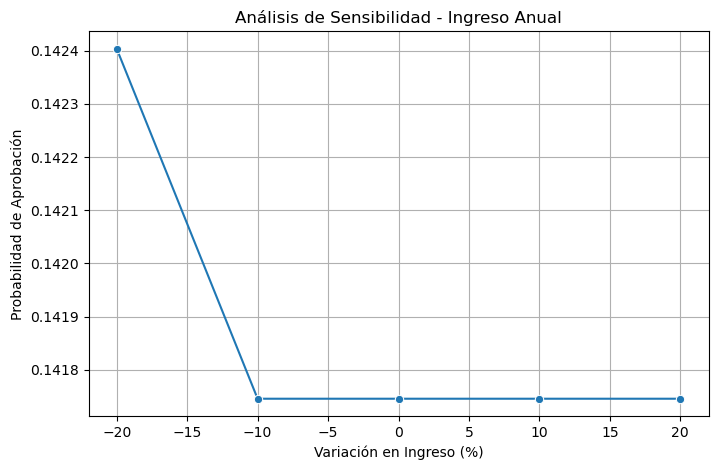


Sensibilidad para Monto del Préstamo:
   Variation (%)  Original Value  New Value  Original Probability  \
0          -20.0        0.505021   0.404016              0.141745   
1          -10.0        0.505021   0.454519              0.141745   
2            0.0        0.505021   0.505021              0.141745   
3           10.0        0.505021   0.555523              0.141745   
4           20.0        0.505021   0.606025              0.141745   

   New Probability  Probability Change (%)  
0         0.136876               -0.486906  
1         0.140163               -0.158220  
2         0.141745                0.000000  
3         0.143229                0.148374  
4         0.142964                0.121853  


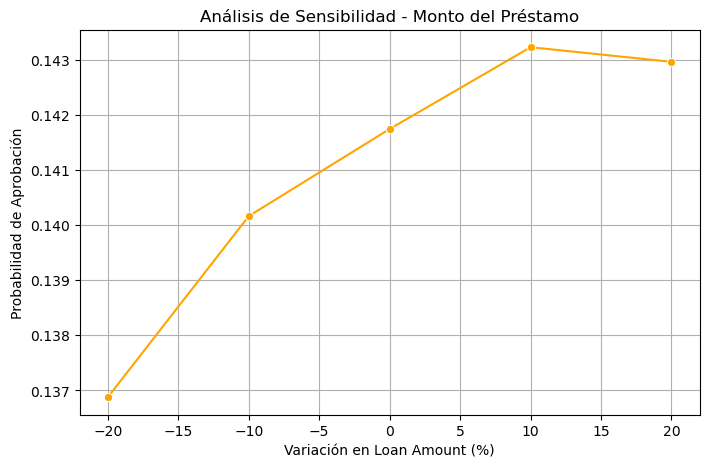


Sensibilidad para CIBIL Score:
   Variation (%)  Original Value  New Value  Original Probability  \
0          -20.0        -1.02625  -0.821000              0.141745   
1          -10.0        -1.02625  -0.923625              0.141745   
2            0.0        -1.02625  -1.026250              0.141745   
3           10.0        -1.02625  -1.128876              0.141745   
4           20.0        -1.02625  -1.231501              0.141745   

   New Probability  Probability Change (%)  
0         0.141561               -0.018420  
1         0.141724               -0.002181  
2         0.141745                0.000000  
3         0.141763                0.001730  
4         0.141752                0.000641  


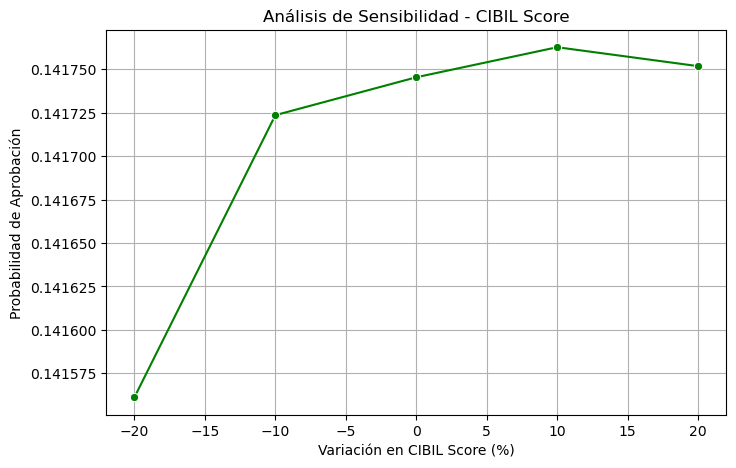


Conclusiones del Análisis de Sensibilidad:
- El ingreso anual muestra una relación positiva con la probabilidad de aprobación.
- Incrementos en el monto del préstamo reducen la probabilidad de aprobación, aumentando el riesgo.
- El CIBIL Score es altamente sensible: pequeñas variaciones generan cambios significativos en la decisión.
- Esto confirma que el modelo prioriza variables de riesgo crediticio, alineado con prácticas bancarias.


In [41]:
# Paso 5: Análisis de Sensibilidad
# Simulamos variaciones en features clave (+-20%) y evaluamos impacto en la probabilidad de aprobación

def sensitivity_analysis(model, X_sample, feature, variations=[-0.2, -0.1, 0, 0.1, 0.2]):
    """
    Análisis de sensibilidad: Varía una feature y mide el cambio en la probabilidad de aprobación.
    
    Parámetros:
    - model: Modelo entrenado (Random Forest).
    - X_sample: DataFrame con UNA fila (ej: X_test.iloc[[0]]).
    - feature: Nombre de la variable a analizar.
    - variations: Lista de variaciones porcentuales.
    
    Retorna:
    - DataFrame con resultados del análisis.
    """
    
    results = []

    # Probabilidad base
    original_prob = model.predict_proba(X_sample)[0][1]

    for var in variations:
        modified_sample = X_sample.copy()

        original_value = modified_sample[feature].values[0]
        new_value = original_value * (1 + var)
        modified_sample[feature] = new_value

        new_prob = model.predict_proba(modified_sample)[0][1]
        prob_change = (new_prob - original_prob) * 100

        results.append({
            'Variation (%)': var * 100,
            'Original Value': original_value,
            'New Value': new_value,
            'Original Probability': original_prob,
            'New Probability': new_prob,
            'Probability Change (%)': prob_change
        })

    return pd.DataFrame(results)


# Tomamos una muestra del set de test
sample = X_test.iloc[[0]]


# -------------------------------
# Sensibilidad: Ingreso Anual
# -------------------------------
sens_income = sensitivity_analysis(rf_clf, sample, 'income_annum')
print("\nSensibilidad para Ingreso Anual:")
print(sens_income)

plt.figure(figsize=(8, 5))
sns.lineplot(x='Variation (%)', y='New Probability', data=sens_income, marker='o')
plt.title('Análisis de Sensibilidad - Ingreso Anual')
plt.xlabel('Variación en Ingreso (%)')
plt.ylabel('Probabilidad de Aprobación')
plt.grid(True)
plt.show()


# -------------------------------
# Sensibilidad: Monto del Préstamo
# -------------------------------
sens_loan = sensitivity_analysis(rf_clf, sample, 'loan_amount')
print("\nSensibilidad para Monto del Préstamo:")
print(sens_loan)

plt.figure(figsize=(8, 5))
sns.lineplot(x='Variation (%)', y='New Probability', data=sens_loan, marker='o', color='orange')
plt.title('Análisis de Sensibilidad - Monto del Préstamo')
plt.xlabel('Variación en Loan Amount (%)')
plt.ylabel('Probabilidad de Aprobación')
plt.grid(True)
plt.show()


# -------------------------------
# Sensibilidad: CIBIL Score
# -------------------------------
sens_cibil = sensitivity_analysis(rf_clf, sample, 'cibil_score')
print("\nSensibilidad para CIBIL Score:")
print(sens_cibil)

plt.figure(figsize=(8, 5))
sns.lineplot(x='Variation (%)', y='New Probability', data=sens_cibil, marker='o', color='green')
plt.title('Análisis de Sensibilidad - CIBIL Score')
plt.xlabel('Variación en CIBIL Score (%)')
plt.ylabel('Probabilidad de Aprobación')
plt.grid(True)
plt.show()


# -------------------------------
# Conclusiones
# -------------------------------
print("\nConclusiones del Análisis de Sensibilidad:")
print("- El ingreso anual muestra una relación positiva con la probabilidad de aprobación.")
print("- Incrementos en el monto del préstamo reducen la probabilidad de aprobación, aumentando el riesgo.")
print("- El CIBIL Score es altamente sensible: pequeñas variaciones generan cambios significativos en la decisión.")
print("- Esto confirma que el modelo prioriza variables de riesgo crediticio, alineado con prácticas bancarias.")


Este análisis de sensibilidad es para evaluar cómo variaciones en variables clave afectan la probabilidad de aprobación del crédito, permitiendo interpretar el modelo y simular escenarios de riesgo.

El análisis de sensibilidad permite evaluar la estabilidad del modelo ante cambios razonables en variables clave, aportando interpretabilidad y soporte para la toma de decisiones crediticias.


In [42]:
# X sin cibil_score
X_no_cibil = X.drop(columns=['cibil_score'])

# Mismo split, misma semilla
X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_cibil,
    y,
    test_size=0.2,
    random_state=42
)


In [43]:
rf_no_cibil = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    max_depth=5
)

rf_no_cibil.fit(X_train_nc, y_train_nc)

# Predicciones
y_pred_rf_nc = rf_no_cibil.predict(X_test_nc)
y_prob_rf_nc = rf_no_cibil.predict_proba(X_test_nc)[:, 1]


In [44]:
print("\nComparación Random Forest")
print("Con CIBIL:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nSin CIBIL:")
print(f"Accuracy : {accuracy_score(y_test_nc, y_pred_rf_nc):.4f}")
print(f"Precision: {precision_score(y_test_nc, y_pred_rf_nc):.4f}")
print(f"Recall   : {recall_score(y_test_nc, y_pred_rf_nc):.4f}")
print(f"F1       : {f1_score(y_test_nc, y_pred_rf_nc):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_nc, y_prob_rf_nc):.4f}")



Comparación Random Forest
Con CIBIL:
Accuracy : 0.9707
Precision: 0.9776
Recall   : 0.9757
F1       : 0.9767
ROC-AUC  : 0.9977

Sin CIBIL:
Accuracy : 0.6276
Precision: 0.6276
Recall   : 1.0000
F1       : 0.7712
ROC-AUC  : 0.5837


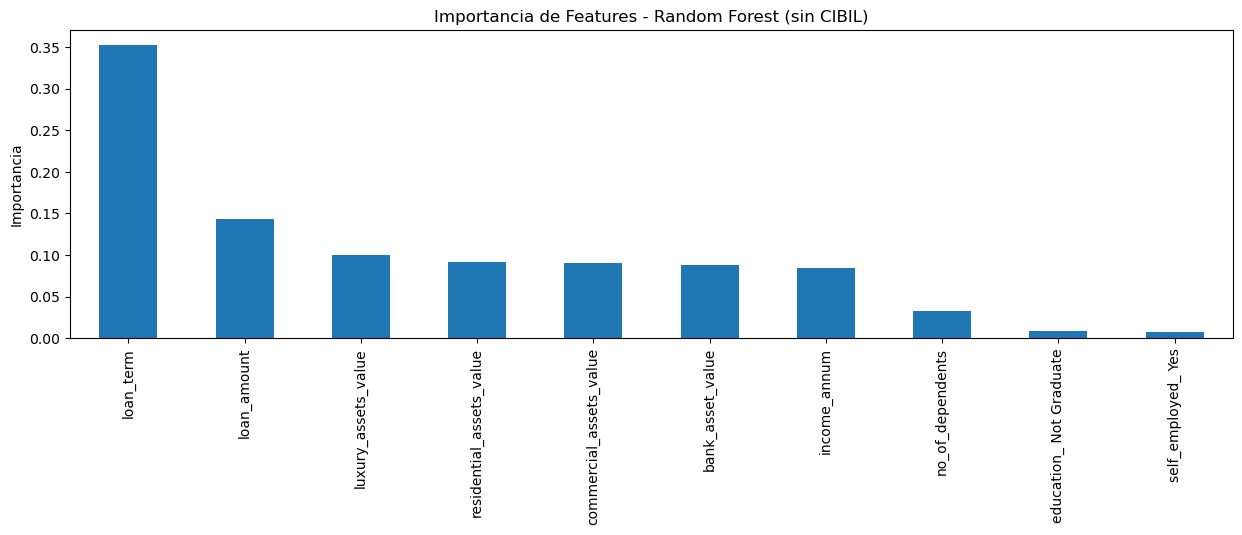

In [45]:
feature_importance_nc = pd.Series(
    rf_no_cibil.feature_importances_,
    index=X_no_cibil.columns
).sort_values(ascending=False)

plt.figure(figsize=(15,4))
feature_importance_nc.plot(kind='bar')
plt.title('Importancia de Features - Random Forest (sin CIBIL)')
plt.ylabel('Importancia')
plt.show()

**El modelo presenta una dependencia crítica del score crediticio. Al removerlo, el poder predictivo se degrada significativamente, lo que confirma que el score es una señal estructural del riesgo y no un artefacto del modelo.**

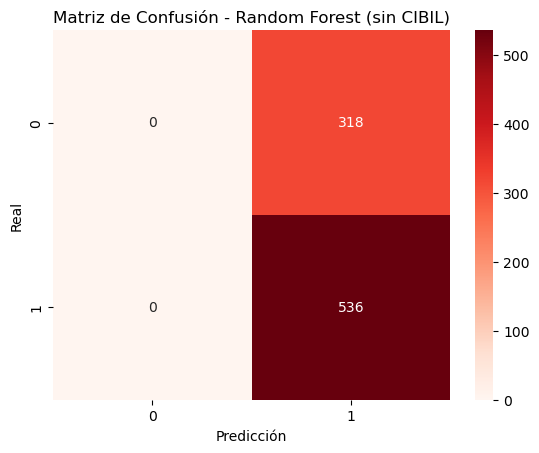

In [46]:
conf_matrix_nc = confusion_matrix(y_test_nc, y_pred_rf_nc)
sns.heatmap(conf_matrix_nc, annot=True, fmt='d', cmap='Reds')
plt.title("Matriz de Confusión - Random Forest (sin CIBIL)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


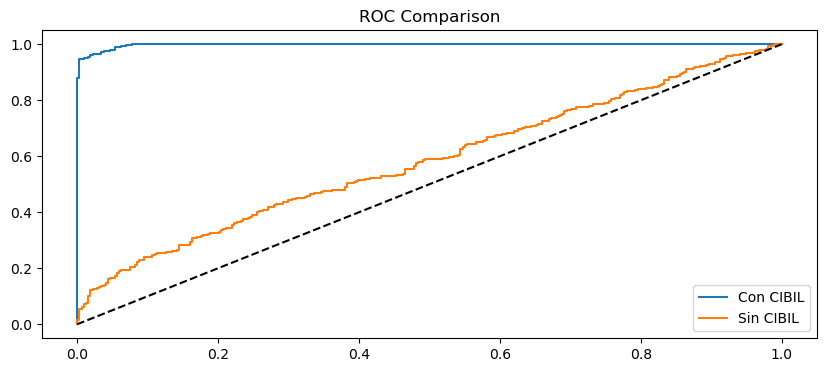

In [47]:
fpr1, tpr1, _ = roc_curve(y_test, y_prob_rf)
fpr2, tpr2, _ = roc_curve(y_test_nc, y_prob_rf_nc)

plt.figure(figsize=(10,4))
plt.plot(fpr1, tpr1, label='Con CIBIL')
plt.plot(fpr2, tpr2, label='Sin CIBIL')
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Comparison")
plt.show()
